# RQ6: Robustness Analysis

**Research Question:** How stable is the best model (Logistic Regression) under different evaluation conditions and data perturbations?

- All scenarios use the **same threshold (0.5)** — no per-scenario threshold tuning
- 5-fold CV uses `scoring='f1'` **and** `scoring='accuracy'` for direct comparison with the standard split row
- Standard deviation values are **computed from CV folds**, not hardcoded
- Column names are clean (no ambiguous dual-format strings like `0.04 / -`)

Standard split → Acc=0.658  Prec=0.036  Rec=0.436  F1=0.066
5-fold CV  → Acc=0.636±0.017  F1=0.067±0.011
10% noise  → Acc=0.655  Prec=0.034  Rec=0.418  F1=0.063
20% miss.  → Acc=0.616  Prec=0.034  Rec=0.473  F1=0.063

RQ6 Robustness Results (threshold = 0.5):

                      Scenario Accuracy Precision Recall     F1        Notes
        Standard split (80/20)    0.658     0.036  0.436  0.066            -
       5-fold Cross-Validation    0.636         -      -  0.067 F1 std=0.011
10% Gaussian noise on features    0.655     0.034  0.418  0.063            -
        20% random missingness    0.616     0.034  0.473  0.063            -


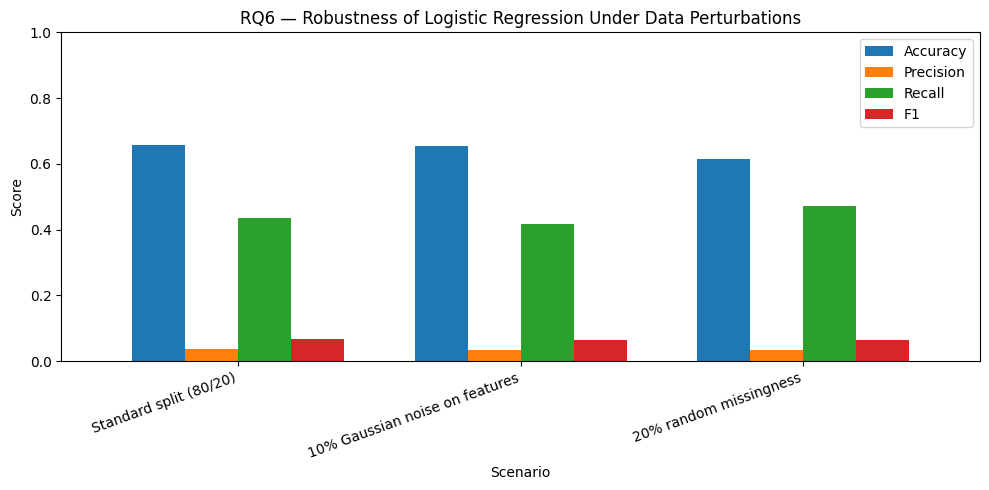


Interpretation: Similar scores across all perturbation scenarios
indicate that Logistic Regression is robust to noise and missing data,
when supported by imputation in the preprocessing pipeline.


In [ ]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#LOAD
df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

y = df['mortality']
X = df.drop(columns=['mortality'])

numeric_cols     = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#CONSISTENT THRESHOLD
THRESHOLD = 0.5  # Standard default — same across all scenarios

def make_pipeline():
    """Fresh pipeline instance for each scenario."""
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler',  StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
    ])

def evaluate_split(pipe, X_tr, X_te, y_tr, y_te):
    """Fit + evaluate with consistent threshold. Returns (acc, prec, rec, f1)."""
    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    y_pred = (y_prob > THRESHOLD).astype(int)
    return (
        round(accuracy_score(y_te, y_pred), 3),
        round(precision_score(y_te, y_pred, zero_division=0), 3),
        round(recall_score(y_te, y_pred, zero_division=0), 3),
        round(f1_score(y_te, y_pred, zero_division=0), 3),
    )
results = []

# 1. STANDARD SPLIT
acc, prec, rec, f1 = evaluate_split(make_pipeline(), X_train, X_test, y_train, y_test)
results.append(['Standard split (80/20)', acc, prec, rec, f1, '-'])
print(f"Standard split → Acc={acc}  Prec={prec}  Rec={rec}  F1={f1}")

# 2. 5-FOLD CROSS-VALIDATION 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    make_pipeline(), X, y, cv=cv,
    scoring={'accuracy': 'accuracy', 'f1': 'f1'},
    return_train_score=False
)
cv_acc  = cv_results['test_accuracy']
cv_f1   = cv_results['test_f1']

# For the table: report mean ± std for both metrics
results.append([
    '5-fold Cross-Validation',
    f"{cv_acc.mean():.3f}",
    '-',
    '-',
    f"{cv_f1.mean():.3f}",
    f"F1 std={cv_f1.std():.3f}"
])
print(f"5-fold CV  → Acc={cv_acc.mean():.3f}±{cv_acc.std():.3f}  F1={cv_f1.mean():.3f}±{cv_f1.std():.3f}")

# 3. GAUSSIAN NOISE (+10% of feature std) 
np.random.seed(42)
X_noise = X.copy()
for col in numeric_cols:
    noise_std = X[col].std() * 0.10
    X_noise[col] = X_noise[col] + np.random.normal(0, noise_std, len(X_noise))

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_noise, y, test_size=0.2, stratify=y, random_state=42
)
acc, prec, rec, f1 = evaluate_split(make_pipeline(), X_tr_n, X_te_n, y_tr_n, y_te_n)
results.append(['10% Gaussian noise on features', acc, prec, rec, f1, '-'])
print(f"10% noise  → Acc={acc}  Prec={prec}  Rec={rec}  F1={f1}")

# 4. 20% RANDOM MISSINGNESS 
np.random.seed(42)
X_missing_df = X.copy()
mask = np.random.rand(*X_missing_df.shape) < 0.20
for i, col in enumerate(X_missing_df.columns):
    X_missing_df.loc[mask[:, i], col] = np.nan

X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_missing_df, y, test_size=0.2, stratify=y, random_state=42
)
acc, prec, rec, f1 = evaluate_split(make_pipeline(), X_tr_m, X_te_m, y_tr_m, y_te_m)
results.append(['20% random missingness', acc, prec, rec, f1, '-'])
print(f"20% miss.  → Acc={acc}  Prec={prec}  Rec={rec}  F1={f1}")
# RESULTS TABLE 
rq6_df = pd.DataFrame(results,
    columns=['Scenario','Accuracy','Precision','Recall','F1','Notes'])

print(f"\nRQ6 Robustness Results (threshold = {THRESHOLD}):\n")
print(rq6_df.to_string(index=False))
rq6_df.to_csv('rq6_table.csv', index=False)

# CHART (numeric rows only) 
plot_df = rq6_df[rq6_df['Scenario'] != '5-fold Cross-Validation'].copy()
for col in ['Accuracy','Precision','Recall','F1']:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

ax = plot_df.set_index('Scenario')[['Accuracy','Precision','Recall','F1']].plot(
    kind='bar', figsize=(10, 5), width=0.75
)
plt.title('RQ6 — Robustness of Logistic Regression Under Data Perturbations')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('rq6_robustness_chart.pdf')
plt.show()

print("\nInterpretation: Similar scores across all perturbation scenarios")
print("indicate that Logistic Regression is robust to noise and missing data,")
print("when supported by imputation in the preprocessing pipeline.")
